# Python для теории вероятностей и статистики

На этом занятии мы покажем, как проводить эксперименты, считать вероятностные характеристики и визуализировать результаты.

Что-то будет повторением первого курса (для тех, кто ходил на курсы «Введение в статистику» или «Введение в ИИ»), будет и что-то новое.

План на сегодня:

1. Работа с массивами данных: NumPy.
2. Метод Монте-Карло: моделируем случайность вместо того, чтобы каждый раз считать по формуле.
3. Характеристики выборки: среднее, медиана, мода, среднеквадратическое отклонение, асимметрия, эксцесс, ковариация, корреляция.
4. Визуализация: гистограммы, эмпирическая функция распределения, перцентили.
5. Символьные вычисления: SymPy.
6. Готовые модели распределений: SciPy.


## Пара приёмов Jupyter/Colab

Google Colab — это, по сути, Jupyter Notebook на сервере Google.

- `?` после объекта показывает справку: `np.mean?` откроет docstring  функции — это быстрее, чем идти
  в документацию.

In [ ]:
import numpy as np


np.mean?

- `%time` перед строкой и `%%time` в начале ячейки — замеряют время выполнения.
- CPU times — суммарное время работы процессора (user + sys), а Wall time — реальное «время по часам», прошедшее от старта до конца ячейки. Wall time включает и время ожидания (диска, сети, других процессов), поэтому обычно Wall time ≥ CPU time.

In [ ]:
%time total = sum(range(2_000_000))
print('результат:', total)

CPU times: user 50.2 ms, sys: 0 ns, total: 50.2 ms
Wall time: 50 ms
результат: 1999999000000


In [ ]:
%%time
_ = np.sin(np.arange(1_000_000))

CPU times: user 22.4 ms, sys: 6.91 ms, total: 29.3 ms
Wall time: 29 ms


- Ячейки Markdown (как эта) поддерживают формулы через `$...$`.

Пример формулы: исходный текст `$\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$` в ячейке Markdown
отрендерится вот так: $\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$.

<!-- ## Зачем нужен «научный» Python -->
## Библиотеки Python для анализа данных

Python — интерпретируемый (код исполняется виртуальной машиной, а не компилируется в машинный код заранее) и динамически типизированный язык (типы переменных определяются
на лету). Поэтому Python-код медленно выполняется и не подходит для тяжёлых вычислений на большом массиве данных.

Проблему решает связка **Python + компилированные библиотеки на C** (например, NumPy) **и Fortran** (например, SciPy). Python выделяет память и передаёт её в быструю, уже скомпилированную библиотеку, которая выполняет всю арифметику.

Мы начнём занятие с рассмотрения возможностей NumPy.


## 1. Работа с массивами данных: NumPy

### 1.1. Массивы и типы данных

Массив NumPy хранит объекты одного типа фиксированного размера. Это отличает его
от обычного списка Python, который может хранить объекты разных типов.

**Полная таблица типов (dtype)**

| Категория | dtype | Байт/элемент | Ускорение расчётов |
|---|---|---|---|
| Целые (знаковые) | `int8`, `int16`, `int32`, `int64` | 1, 2, 4, 8 | ✅ да |
| Целые (беззнаковые) | `uint8`, `uint16`, `uint32`, `uint64` | 1, 2, 4, 8 | ✅ да |
| Вещественные | `float16`, `float32`, `float64` | 2, 4, 8 | ✅ да |
| Комплексные | `complex64`, `complex128` | 8, 16 | ✅ да |
| Булевы | `bool` | 1 | ✅ да |
| Дата/время | `datetime64`, `timedelta64` | 8 | ✅ да (для арифметики дат) |
| Строки фикс. длины | `<U…` (unicode), `<S…` (byte) | N×4 / N×1 | ⚠️ частично |
| Произвольные объекты | `object` | 8 (указатель) | ❌ нет |


Числовые и булевы типы имеют фиксированный размер, они лежат в памяти сплошным блоком. NumPy производит ускорение вычислений за счёт двух механизмов:
1. *Универсальные функции* NumPy (ufunc) — функции вида `np.add`, `np.sin` и тому подобные, которые применяют одну операцию к каждому элементу массива, но сам цикл выполняется не в интерпретаторе Python, а в скомпилированном коде.
2. SIMD — набор инструкций процессора, позволяющих CPU за один такт обрабатывать сразу несколько чисел одного типа.

Оба механизма работают только при известном заранее и одинаковом для всех элементов типе. Поэтому для быстрых вычислений тип массива стоит задавать явно через `dtype`, избегая автоматического определения.



Массив с типом `object` устроен иначе: он хранит не значения, а указатели на разбросанные по памяти Python-объекты, так что каждая операция всё равно идёт через интерпретатор. По скорости это обычный список Python.

Для строк есть отдельные векторизованные функции `np.char`/`np.strings`. Они быстрее цикла на Python, но не дают ускорения, сравнимого с числовыми ufunc, потому что операции со строками переменной длины устроены сложнее, чем поэлементная арифметика с числами фиксированного размера.

**Как NumPy выбирает тип автоматически.** Если не указать `dtype` явно, NumPy сканирует все
элементы массива и берёт самый «старший» тип по иерархии:

$$\text{bool} \to \text{int} \to \text{float} \to \text{complex} \to \text{строка} \to \text{object}.$$

Каждый следующий тип может представить всё, что мог предыдущий (любое целое можно записать как
`float`, любое число — как строку), но не наоборот — так что выбирается тот тип, через который можно представить все элементы массива.


Внутри числового типа NumPy по умолчанию берёт размер, стандартный для вашей системы (обычно `int64`/`float64` на 64-битном компьютере), а не минимально необходимый. Поэтому для экономии памяти `dtype` нужно указывать вручную.


Если же объект настолько большой, что даже `float64` не может его вместить — NumPy как крайний случай переводит тип
в `object`, чтобы незаметно не потерять данные.

In [ ]:
import numpy as np

x = np.array([1, 2, 3], dtype=np.float32)
print(x)
print('тип элемента:', x.dtype)
print('байт на элемент:', x.itemsize)

# пример с потерей данных
small = np.array([100, 100], dtype=np.int8)
print(small + small)                                       # [-56 -56], а не [200 200] -- переполнение int8
a = np.array([1, 2, 3]); a[0] = 3.7; print(a)                # [3 2 3] -- дробная часть потеряна

# автоматический выбор типа: побеждает «старший» по иерархии bool -> int -> float -> complex -> строка -> object
print(np.array([True, 1]).dtype)        # int64
print(np.array([2, 2.4, -4]).dtype)     # float64    -- одно дробное «утянуло» весь массив
print(np.array([1, 2 + 3j]).dtype)      # complex128
print(np.array([1, 'a']).dtype)          # <U21       -- число стало строкой '1'
print(np.array([1, None]).dtype)         # object     -- деваться некуда, None ничем не выразить

[1. 2. 3.]
тип элемента: float32
байт на элемент: 4
[-56 -56]
[3 2 3]
int64
float64
complex128
<U21
object


### 1.2. Вместо циклов: векторизация (универсальные функции)

Векторизация — это подход, при котором операции совершаются сразу над всем массивом, без явного цикла `for` на Python.

Функции вида `np.sin`, `np.exp`, `np.sqrt` и так далее — универсальные функции (**ufunc**). Они применяются к массиву поэлементно, но цикл выполняется внутри скомпилированного кода NumPy, а не на уровне интерпретатора Python — оттого они быстрые.

**Основные универсальные функции NumPy (их около 90)**

| Категория | Функции |
|---|---|
| Арифметика | `add`, `subtract`, `multiply`, `divide`, `floor_divide`, `power`, `mod`, `negative`, `abs`, `sign` |
| Степени/логарифмы | `sqrt`, `cbrt`, `square`, `exp`, `exp2`, `log`, `log2`, `log10`, `expm1`, `log1p` |
| Тригонометрия | `sin`, `cos`, `tan`, `arcsin`, `arccos`, `arctan`, `arctan2`, `hypot` |
| Гиперболические | `sinh`, `cosh`, `tanh`, `arcsinh`, `arccosh`, `arctanh` |
| Округление | `round`/`around`, `floor`, `ceil`, `trunc`, `rint` |
| Сравнение | `greater`, `greater_equal`, `less`, `less_equal`, `equal`, `not_equal`, `maximum`, `minimum` |
| Логика | `logical_and`, `logical_or`, `logical_not`, `logical_xor` |
| Битовые | `bitwise_and`, `bitwise_or`, `bitwise_xor`, `invert`, `left_shift`, `right_shift` |
| Проверки float | `isnan`, `isinf`, `isfinite` |

Операторы `+`, `-`, `*`, `/`, `**`, `<`, `==` на массивах — это вызовы самих же ufunc'ов через перегрузку оператора. Класс `np.ndarray` сам определяет, что делать при вызове данных операторов, поэтому если `a`,`b` — массивы типа `np.ndarray`, то запись `a + b` под капотом выполняется как `np.add(a, b)`.


Сравним ufunc со стандартным Python-модулем `math`, у которого такой оптимизации нет.

In [ ]:
import math
import time

n = 2_000_000
data_list = list(range(n))
data_array = np.arange(n)

start = time.time()
result_loop = [math.sin(i) for i in data_list]   # чистый Python: цикл на уровне интерпретатора
time_loop = time.time() - start

start = time.time()
result_vec = np.sin(data_array)                    # NumPy ufunc: цикл внутри скомпилированного кода
time_vec = time.time() - start

print(f'list comprehension + math.sin: {time_loop:.3f} с')
print(f'np.sin (векторизация):         {time_vec:.3f} с')
print(f'ускорение: {time_loop / time_vec:.1f}x')

list comprehension + math.sin: 0.265 с
np.sin (векторизация):         0.044 с
ускорение: 6.0x


### Методы ufunc: `.reduce()`, `.accumulate()`, `.outer()`

Все три метода берут **бинарную ufunc-операцию** (обозначим её `op`: это может быть `add`, `multiply`, `max`) и применяют её ко всему массиву.

- **`ufunc.reduce(x)`** последовательно применяет `op` к элементам массива слева направо, схлопывая их в одно значение:
  ```
  op(op(op(x[0], x[1]), x[2]), x[3]), ...
  ```
  Результат — скаляр (или массив меньшей размерности, если задан `axis`). Это обобщение операций типа «сумма всех», «произведение всех», «максимум из всех».

- **`ufunc.accumulate(x)`** делает то же самое, что `.reduce()`, но не выбрасывает промежуточные шаги, а возвращает их все. Результат — массив той же формы, что и `x`, где i-й элемент — результат `.reduce()` над первыми `i+1` элементами. Это «накопительный» вариант операции.

- **`ufunc.outer(a, b)`** применяет `op` ко всем возможным парам элементов из `a` и `b` (декартово произведение индексов). Результат — двумерная таблица формы `(len(a), len(b))`, где ячейка `(i, j)` = `op(a[i], b[j])`. Это способ построить «таблицу сочетаний» для любой бинарной операции.

In [ ]:
import numpy as np

x = np.array([1, 2, 3, 4])

# reduce — свёртка в число
print(np.add.reduce(x))         # 10, то же, что np.sum(x)
print(np.multiply.reduce(x))    # 24, то же, что np.prod(x)

# accumulate — накопительная свёртка
print(np.add.accumulate(x))       # [ 1  3  6 10]
print(np.multiply.accumulate(x))  # [ 1  2  6 24]

# outer — таблица попарных результатов
a = np.array([1, 2])
b = np.array([10, 20])
print(np.add.outer(a, b))
# [[11 21]
#  [12 22]]

# эквивалент через broadcasting
print(a[:, None] + b[None, :])
# [[11 21]
#  [12 22]]

10
24
[ 1  3  6 10]
[ 1  2  6 24]
[[11 21]
 [12 22]]
[[11 21]
 [12 22]]


#### `np.vectorize`: удобно, но не быстро

`np.vectorize` берёт обычную одноместную Python-функцию и оборачивает её так,
чтобы она принимала массивы и применялась поэлементно. Выглядит как векторизация,
но фактически это обычный цикл `for` на Python, который вызывает функцию по одному разу на
каждый элемент.

Это удобный синтаксис, но не ускорение.

In [ ]:
def classify(x):
    if x < 10:
        return 'низкий'
    elif x < 20:
        return 'средний'
    else:
        return 'высокий'

classify_vec = np.vectorize(classify)
classify_vec(np.array([5, 15, 25]))

array(['низкий', 'средний', 'высокий'], dtype='<U7')

Сравним с настоящей векторизацией той же задачи через `np.where`. На реальных данных разница во времени существенная.

`np.where(условие, значение_если_true, значение_если_false)` — векторизованный аналог условного оператора.

In [ ]:
import time

def safe_divide(a, b):
    if b == 0:
        return 0.0
    return a / b

vec_safe_divide = np.vectorize(safe_divide, otypes=[float])

n = 500_000
a = np.random.rand(n)
b = np.random.randint(0, 5, size=n).astype(float)   # иногда 0

start = time.time()
result_vectorize = vec_safe_divide(a, b)
time_vectorize = time.time() - start

start = time.time()
result_where = np.where(b == 0, 0.0, a / b)   # обе ветки считаются для всех элементов сразу
time_where = time.time() - start

print(f'np.vectorize: {time_vectorize:.3f} с')
print(f'np.where:     {time_where:.3f} с')
print(f'ускорение np.where: {time_vectorize / time_where:.1f}x')
print('результаты совпадают:', np.allclose(result_vectorize, result_where))

np.vectorize: 0.182 с
np.where:     0.004 с
ускорение np.where: 43.3x
результаты совпадают: True


/tmp/ipykernel_1708/2926927826.py:19: RuntimeWarning: divide by zero encountered in divide
  result_where = np.where(b == 0, 0.0, a / b)   # обе ветки считаются для всех элементов сразу


Если задачу можно выразить через `np.where` / `np.select` / булеву маску — используйте их. `np.vectorize` — запасной вариант для функций с настоящей Python-логикой, которую иначе не выразить (внешние вызовы, рекурсия, сложные ветвления).

### 1.3. Суммирование, умножение и скалярное произведение

Оператор `*` между двумя массивами работает **поэлементно**. Если нужен не поэлементный результат, а  **скалярное произведение**, в NumPy оно считается оператором
`@` (это то же самое, что `np.dot`).

Пример: в заказе есть количества товаров `quantities` и цены за единицу `prices`. Стоимость по
каждой позиции — поэлементное произведение, а сумма заказа целиком — их скалярное произведение.

In [ ]:
quantities = np.array([3, 2, 5, 1])
prices = np.array([100, 250, 40, 150])

line_costs = quantities * prices     # поэлементно: стоимость каждой позиции
total = quantities @ prices           # скалярное произведение: сумма заказа одним числом

print('стоимость по позициям:', line_costs)
print('сумма заказа (через @):        ', total)
print('сумма заказа (через np.sum):   ', np.sum(line_costs))

стоимость по позициям: [300 500 200 150]
сумма заказа (через @):         1150
сумма заказа (через np.sum):    1150


#### Задача 1. Сумма заказа

Даны данные о товарах — их количества  `quantities` и цены за единицу товара `prices` (оба массива одинаковой длины).
Посчитайте:
1. `line_costs` — стоимость по каждой позиции (поэлементное произведение).
2. `total_dot` — сумму заказа (через оператор `@`).
3. `total_sum` — ту же сумму через `np.sum(line_costs)` — и убедитесь, что оба способа совпадают.

In [ ]:
quantities = np.array([4, 1, 10, 3])
prices = np.array([120, 899, 25, 60])

# Ваше решение здесь

# Решение
line_costs = quantities * prices
total_dot = quantities @ prices
total_sum = np.sum(line_costs)

print('стоимость по позициям:', line_costs)
print('итого (dot):', total_dot, ' итого (sum):', total_sum)

стоимость по позициям: [480 899 250 180]
итого (dot): 1809  итого (sum): 1809


In [ ]:
# Проверка
assert line_costs.tolist() == [480, 899, 250, 180]
assert total_dot == total_sum == 1809
print('проверка пройдена')

проверка пройдена


### 1.4. От вектора к матрице: матричное умножение

Тот же оператор `@`, применённый к двум **матрицам**, — это матричное умножение: элемент `(i, j)`
результата — скалярное произведение `i`-й строки первой матрицы и `j`-го столбца второй.

Ту же операцию выполняет команда `np.matmul`.

Рассмотрим пример:
- матрица `quantities`, строки — заказы, столбцы — товары;
- матрица `prices`, строки — товары, столбцы —
поставщики (у каждого своя цена на каждый товар).

Тогда `quantities @ prices` — таблица
«стоимость каждого заказа у каждого поставщика».

In [ ]:
quantities = np.array([
    [2, 0, 1],   # заказ 0: 2 ед. товара A, 0 ед. товара B, 1 ед. товара C
    [0, 3, 2],   # заказ 1
    [1, 2, 1],   # заказ 2
])
prices = np.array([
    [10, 12, 11],   # товар A: цена у поставщика 0, 1, 2
    [ 5,  4,  6],   # товар B
    [ 8,  7,  9],   # товар C
])

total_cost = quantities @ prices   # (3 заказа) x (3 поставщика)
print(total_cost)

[[28 31 31]
 [31 26 36]
 [28 27 32]]


In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print('1D одинаково:', a @ b, np.dot(a, b))

# батч из трёх матриц 2 x 2 -- как если бы считали для трёх заказов сразу
batch_A = np.random.rand(3, 2, 2)
batch_B = np.random.rand(3, 2, 2)

print('@ (matmul), форма результата:', (batch_A @ batch_B).shape)        # (3, 2, 2) -- по матрице на батч
print('np.dot, форма результата:    ', np.dot(batch_A, batch_B).shape)   # (3, 2, 3, 2) -- совсем не то

print('np.dot(2, 3) =', np.dot(2, 3))   # для чисел работает как обычное умножение
# 2 @ 3   -- а это уже TypeError: скаляры "@" не принимает

1D одинаково: 32 32
@ (matmul), форма результата: (3, 2, 2)
np.dot, форма результата:     (3, 2, 3, 2)
np.dot(2, 3) = 6


### `@` и `np.dot`: в чём разница

Для того, с чем мы работаем в этом курсе — векторы (одномерные массивы) и матрицы (двумерные массивы), — операторы `@` и `np.dot` дают
**одинаковый** результат, это взаимозаменяемые записи одного и того же. Расхождения появляются на данных других размеров.

**Тензор** — это многомерная матрица: например, `A = B = np.ones((2, 3, 4))` — две матрицы (батч размера 2) единиц размера 2 на 3 на 4. Можно думать, что каждая из них — это две склеенные друг с другом матрицы 3 на 4. Если вызвать оператор `A @ B` (или `np.matmul(A, B)`), каждая подматрица 3 на 4 в `A` умножается на соответствующую подматрицу в `B`, и результаты также «склеиваются» — то есть `@` выполняет батчевое умножение матриц, а не сворачивает всё в одно число.

Это же правило работает и тогда, когда размерности совпадают не полностью, а согласуются по правилам broadcasting: например, если `A` имеет форму `(5, 3, 4)`, а `B` — форму `(4, 2)` (одна матрица без батч-измерения), то `A @ B` — это умножение каждой из 5 подматриц `A` на одну и ту же матрицу `B`, результат формы `(5, 3, 2)`.

Есть ещё оператор `np.dot(A, B)`, он устроен совсем иначе и эквивалентен следующему Python-коду:

```python
# dot(A, B)[i, j, k, m] = sum(A[i, j, :] * B[k, :, m])
```

То есть `np.dot` сворачивает последнюю ось первого массива с предпоследней осью второго по всем комбинациям оставшихся индексов. На практике такое редко используется. Поэтому для тензоров и батчей матриц стоит использовать `@` (`np.matmul`), а не `np.dot`.

| Объект | `@` (= `np.matmul`) | `np.dot` |
|---|---|---|
| Число (скаляр) | Ошибка — `@` требует минимум 1D-массивы | Обычное умножение |
| Вектор (1D) | Скалярное произведение | То же самое |
| Матрица (2D) | Матричное умножение | То же самое |
| (3D и выше) | «Батч»: независимое умножение каждой пары матриц по отдельности | Свёртка по всем осям сразу — результат другой формы, обычно не то, что нужно |

> Для скаляров и батчей матриц (несколько матриц сразу) оператор `@` — правильный выбор. В этом курсе достаточно запомнить, что для векторов и матриц разницы нет, а дальше — по умолчанию используйте `@`.



#### Задача 2. Самый дешёвый поставщик

Для каждого заказа найдите поставщика с наименьшей стоимостью (`np.argmin` с `axis=1` по строкам
`total_cost`).

In [ ]:
# Ваше решение здесь

# Решение
cheapest_supplier = np.argmin(total_cost, axis=1)
print('самый дешёвый поставщик для каждого заказа:', cheapest_supplier)

самый дешёвый поставщик для каждого заказа: [0 1 1]


In [ ]:
# Проверка
assert total_cost.shape == (3, 3)
assert cheapest_supplier.tolist() == [0, 1, 1]
print('проверка пройдена')

проверка пройдена


### 1.5. Форма, индексация, срезы

Массив может иметь произвольное число измерений; `shape` показывает размер по каждому из них.
Синтаксис срезов такой же, как у списков, но применяется отдельно к каждой оси через запятую.

In [ ]:
X = np.array([[1, 2, 3], [4, 5, 6]])
print(X.shape)          # (2, 3): 2 строки, 3 столбца

print(X[:, 0])            # весь 0-й столбец
print(X[0, :])             # вся 0-я строка
print(X[:, 1:])             # все строки, столбцы с 1-го до конца
print(X[:, ::-1])            # все строки, столбцы в обратном порядке

(2, 3)
[1 4]
[1 2 3]
[[2 3]
 [5 6]]
[[3 2 1]
 [6 5 4]]


### 1.6. Работа с памятью: срез — это *view*, «умная» индексация — это *copy*

Не все способы выбрать часть массива одинаковы с точки зрения памяти.

- Срез (`x[:3]`, `x[:, 1]` и тому подобные) создаёт **view** — новый объект, который смотрит на ту же память, что и исходный массив. Изменение view меняет оригинал, и наоборот.
- «Умная» (fancy) индексация — индексация списком, массивом индексов или булевой маской (`x[[0, 1, 2]]`, `x[mask]`) — создаёт новый, независимый массив (**копию**), с которым можно спокойно работать, не опасаясь за сохранность изначальных данных.

Кстати, у массивов есть метод `.view()`, который явно создаёт view с тем же буфером памяти, но иногда с другой интерпретацией данных — например, тот же участок памяти можно посмотреть под другим dtype: `x.view(np.int8)` покажет побайтовое представление float-массива. Он полезен, когда нужно переинтерпретировать одни и те же байты как другой тип, не копируя данные (в отличие от среза, который сохраняет исходный тип, `.view()` позволяет ещё и менять «взгляд» на тип).

In [ ]:
x = np.arange(5)

y = x[:3]          # СРЕЗ -> view (общая память с x)
z = x[[0, 1, 2]]  # ИНДЕКСАЦИЯ СПИСКОМ -> copy (независимая память)

x[0] = 999

print('x:', x)
print('y (срез, view):        ', y)   # изменился вместе с x
print('z (fancy index, copy): ', z)   # НЕ изменился

x: [999   1   2   3   4]
y (срез, view):         [999   1   2]
z (fancy index, copy):  [0 1 2]


#### Задача 3. Где на самом деле лежат данные

Дан массив показаний датчика `readings`. Получите первые 3 значения срезом в `first_three` и те
же первые 3 значения — индексацией списком `[0, 1, 2]` в `first_three_copy`. Затем измените
`first_three[0] = -1` и убедитесь, что `readings` тоже изменился, а `first_three_copy` — нет.

In [ ]:
readings = np.array([21.3, 20.9, 19.8, 22.1, 21.7, 20.5])

# Ваше решение здесь

# Решение
first_three = readings[:3]
first_three_copy = readings[[0, 1, 2]]

first_three[0] = -1

print('readings:         ', readings)
print('first_three:      ', first_three)
print('first_three_copy: ', first_three_copy)

readings:          [-1.  20.9 19.8 22.1 21.7 20.5]
first_three:       [-1.  20.9 19.8]
first_three_copy:  [21.3 20.9 19.8]


In [ ]:
# Проверка
assert readings[0] == -1, 'срез -- view, изменение first_three должно было затронуть readings'
assert first_three_copy[0] == 21.3, 'fancy index -- copy, first_three_copy не должен был измениться'
print('проверка пройдена')

проверка пройдена


### 1.7. Маскирование: временно «прячем» часть данных

`numpy.ma.masked_array` помечает часть элементов как отсутствующие, не меняя форму массива и не удаляя данные физически. Это удобно, если, например, часть измерений — явный брак датчика и его нужно исключить из статистики, сохранив позиции остальных значений.

In [ ]:
from numpy import ma

readings = np.array([21.3, 20.9, -999.0, 22.1, 21.7, -999.0, 20.5])   # -999 -- код ошибки датчика

masked_readings = ma.masked_array(readings, mask=(readings == -999.0))
print(masked_readings)
print('среднее без учёта бракованных значений:', masked_readings.mean())
print('обычное np.mean (без маски) было бы:    ', readings.mean())

[21.3 20.9 -- 22.1 21.7 -- 20.5]
среднее без учёта бракованных значений: 21.300000000000004
обычное np.mean (без маски) было бы:     -270.2142857142857


#### Задача 4. Убираем выбросы через маску

Дана выборка `sample` с несколькими явными выбросами. Постройте маскированный массив, в котором
скрыты все значения, отличающиеся от медианы более чем на 3 (
`np.abs(sample - np.median(sample)) > 3`), и посчитайте среднее и стандартное отклонение по
немаскированным данным.

**Примечание.** Методы `.mean()`, `.std()` у `ma.masked_array` автоматически игнорируют
замаскированные элементы.

In [ ]:
sample = np.array([5.1, 4.8, 5.3, 4.9, 5.0, 25.0, 5.2, -18.0, 4.7, 5.1])

# Ваше решение здесь

# Решение
mask = np.abs(sample - np.median(sample)) > 3
clean = ma.masked_array(sample, mask=mask)

clean_mean = clean.mean()
clean_std = clean.std(ddof=1)
print('маска:  ', mask)
print('среднее по очищенным данным:', clean_mean)
print('std по очищенным данным:    ', clean_std)

маска:   [False False False False False  True False  True False False]
среднее по очищенным данным: 5.0125
std по очищенным данным:     0.2031009601158989


In [ ]:
# Проверка
assert mask.sum() == 2, 'должно быть найдено ровно 2 выброса (25.0 и -18.0)'
assert np.isclose(clean_mean, np.mean([5.1, 4.8, 5.3, 4.9, 5.0, 5.2, 4.7, 5.1]))
print('проверка пройдена')

проверка пройдена


## 2. Метод Монте-Карло

### 2.1. Генераторы случайных чисел

`np.random` — источник случайности в NumPy. Параметр `seed` фиксирует стартовую точку генератора: с одним
и тем же `seed` результат воспроизводится один в один.

In [ ]:
np.random.seed(0)

print(np.random.rand(3))                     # 3 числа равномерно на [0, 1)
print(np.random.randint(1, 7, size=5))         # 5 бросков кости: целые от 1 до 6
print(np.random.choice(['орёл', 'решка'], size=5))  # случайный выбор из списка
print(np.random.normal(0, 1, size=3))           # 3 числа из стандартного нормального распределения

[0.5488135  0.71518937 0.60276338]
[4 2 4 6 3]
['орёл' 'решка' 'орёл' 'орёл' 'орёл']
[-0.1730696  -1.76165167 -0.08767307]


### 2.2. Идея метода

Вероятность события можно оценить, если смоделировать много экспериментов и посчитать долю интересующих исходов среди них. Это и есть **метод Монте-Карло**.

#### Задача 5. Оценка вероятности через симуляцию

Смоделируйте 200 000 бросков игральной кости (`np.random.randint`) и с помощью **булевой маски**
(без единого `for`) посчитайте эмпирическую вероятность того, что выпадет число, большее либо
равное 5. Сравните с теоретической вероятностью $1/3$.

In [ ]:
np.random.seed(0)

# Ваше решение здесь

# Решение
rolls = np.random.randint(1, 7, size=200_000)
mask = rolls >= 5
empirical_p = np.mean(mask)

print(f'эмпирическая вероятность: {empirical_p:.4f}')
print(f'теоретическая вероятность: {1/3:.4f}')

эмпирическая вероятность: 0.3342
теоретическая вероятность: 0.3333


In [ ]:
# Проверка
assert rolls.shape == (200_000,)
assert np.isclose(empirical_p, 1/3, atol=0.01)
print('проверка пройдена')

проверка пройдена


### 2.3. Точность

Эмпирическая вероятность выше не равна в точности теоретической `1/3`, но она к ней близка. Оценка происходит по случайной выборке, результат отличается от
запуска к запуску (попробуйте поставить другой `seed`). Чем больше экспериментов — тем меньше это отклонение.

> Не сравнивайте числа типа `float` и тем более результаты симуляций  оператором `==`, лучше использовать оператор `np.isclose()` — он сравнит значения с учётом погрешности. Для сравнения массивов используйте `np.allclose(a, b)`.

In [ ]:
print(0.1 + 0.2)
print(0.1 + 0.2 == 0.3)             # False -- ошибка округления
print(np.isclose(0.1 + 0.2, 0.3))   # True

0.30000000000000004
False
True


#### Задача 6. Проверка эмпирического и теоретического среднего

Смоделируйте 100 000 значений из стандартного нормального распределения (`np.random.normal(0, 1,
size=100000)`) и проверьте через `np.isclose` с параметром `atol=0.01`, что выборочное
среднее близко к теоретическому матожиданию 0.

Продемонстрируйте, что проверка через
`==` не сработала бы никогда, даже для точного совпадения матожиданий.

In [ ]:
np.random.seed(2)

# Ваше решение здесь

# Решение
sample_normal = np.random.normal(0, 1, size=100_000)
sample_mean = np.mean(sample_normal)

correct_check = np.isclose(sample_mean, 0, atol=0.01)
naive_check = (sample_mean == 0)

print('выборочное среднее:', sample_mean)
print('np.isclose(mean, 0, atol=0.01):', correct_check)
print('mean == 0 (наивно, почти всегда False):', naive_check)

выборочное среднее: -0.0032692104037689014
np.isclose(mean, 0, atol=0.01): True
mean == 0 (наивно, почти всегда False): False


In [ ]:
# Проверка
assert correct_check
assert naive_check == False
print('проверка пройдена')

проверка пройдена


### 2.4. Бутстрэп (пересемплирование)

Иногда нужно понять, насколько сильно мог бы измениться результат (например, среднее), если бы
данные оказались немного другими. Для этого много раз строят новую выборку **того же размера**,
выбирая элементы исходных данных случайно и с возвращением — это называется **бутстрэп
(bootstrap)**.

Обычно бутстрэп строится через `np.random.choice` по индексам, чтобы выборка была независимой копией исходных данных.

In [ ]:
np.random.seed(1)
data = np.array([12.1, 9.4, 15.0, 11.2, 8.8, 13.7, 10.5, 14.2])

n_boot = 2000
idx = np.random.choice(len(data), size=(n_boot, len(data)), replace=True)   # n_boot строк индексов
boot_samples = data[idx]              # манипуляции над выборкой не поменяют исходные данные
boot_means = boot_samples.mean(axis=1)  # среднее по каждой строке

print('среднее по исходным данным:  ', data.mean())
print('среднее по бутстреп-средним: ', boot_means.mean())
print('разброс бутстрэп-средних (std):', boot_means.std(ddof=1))

среднее по исходным данным:   11.8625
среднее по бутстреп-средним:  11.88555625
разброс бутстрэп-средних (std): 0.7468077929767221


#### Задача 7. Бутстрэп и независимость памяти

Дан массив `data`. Постройте одну бутстрэп-выборку `boot_sample` того же размера, что
и `data` (используйте `np.random.choice(len(data), size=len(data), replace=True)` для индексов),
затем измените первый элемент `boot_sample` и убедитесь, что массив `data` при этом не поменялся.

In [ ]:
np.random.seed(1)
data = np.array([12.1, 9.4, 15.0, 11.2, 8.8, 13.7])

# Ваше решение здесь

# Решение
idx = np.random.choice(len(data), size=len(data), replace=True)
boot_sample = data[idx]
boot_sample[0] = -1000            # меняем бутстрэп-выборку

In [ ]:
# Проверка
assert boot_sample.shape == data.shape
assert not np.any(data == -1000), 'исходные данные не должны были измениться'
print('data:        ', data)
print('boot_sample: ', boot_sample)
print('проверка пройдена: изменение boot_sample не затронуло data')

data:         [12.1  9.4 15.  11.2  8.8 13.7]
boot_sample:  [-1000.     11.2     8.8    12.1     9.4    11.2]
проверка пройдена: изменение boot_sample не затронуло data


### 2.5. Сумма двух костей

Иногда точный ответ можно получить и без единого случайного числа — если эксперимент предполагает небольшое число исходов, достаточно перебрать все комбинации, чтобы получить значение нужной вероятностной характеристики.

Например, пусть нужно посчитать, чему равна вероятность того, что в результате броска двух игральных кубиков в сумме будет 7 очков. Для этого построим таблицу, в которой по горизонтали будет сумма очков одного кубика, по вертикали — сумма очков другого кубика, а в ячейке (i, j) будет их сумма. Такую таблицу удобно построить через broadcasting: эта процедура добавляет измерения. Например, `a[:, None]` добавит измерение справа (если размер массива был, скажем (2,), то станет (2, 1). По сути, таким образом можно транспонировать массивы.

In [ ]:
# пример broadcasting на одномерных массивах
a = np.arange(1, 7)
print('а: ', a)
print('Размер а: ', a.shape)
print('a[:, None]: \n', a[:, None])
print('Размер a[:, None]: ', a[:, None].shape)

а:  [1 2 3 4 5 6]
Размер а:  (6,)
a[:, None]: 
 [[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
Размер a[:, None]:  (6, 1)


Зададим массив граней `faces`. Если растянуть один вектор граней в столбец (`faces[:, None]`), а другой оставить строкой, операция `+` сама построит таблицу всех пар сумм.

In [ ]:
faces = np.arange(1, 7)
exact_table = faces[:, None] + faces[None, :]   # таблица 6 x 6 : все суммы двух костей
exact_p7 = np.mean(exact_table == 7)             # точная вероятность суммы 7 = 6/36 = 1/6

print(exact_table)
print('точная вероятность P(сумма = 7):', exact_p7, ' (=6/36)')

[[ 2  3  4  5  6  7]
 [ 3  4  5  6  7  8]
 [ 4  5  6  7  8  9]
 [ 5  6  7  8  9 10]
 [ 6  7  8  9 10 11]
 [ 7  8  9 10 11 12]]
точная вероятность P(сумма = 7): 0.16666666666666666  (=6/36)


#### Задача 8. Сверяем точный расчёт и симуляцию

Смоделируйте 200 000 бросков двух костей (дважды примените `np.random.randint`) и посчитайте вероятность того, что сумма граней равна 7. Сравните с точным значением
`exact_p7`, полученным выше через broadcasting.

Как и в задаче 5, совпадение будет близким, но
не точным.

In [ ]:
np.random.seed(3)

# Ваше решение здесь

# Решение
die1 = np.random.randint(1, 7, size=200_000)
die2 = np.random.randint(1, 7, size=200_000)
sums = die1 + die2
empirical_p7 = np.mean(sums == 7)

print('эмпирическая вероятность (симуляция):', empirical_p7)
print('точная вероятность (broadcasting):    ', exact_p7)

эмпирическая вероятность (симуляция): 0.16708
точная вероятность (broadcasting):     0.16666666666666666


In [ ]:
# Проверка
assert sums.shape == (200_000,)
assert np.isclose(empirical_p7, exact_p7, atol=0.01)
print('проверка пройдена')

проверка пройдена


## 3. Характеристики выборки: функции агрегации

Почти все характеристики выборки — среднее, медиана, дисперсия и так далее — это агрегирующие функции: они «схлопывают» массив данных в одно число (или меньшее количество чисел). Сначала разберёмся с механикой агрегации в целом, а затем применим её к настоящей выборке.

Самые ходовые агрегирующие функции собраны в таблице ниже, а также указано, откуда они берутся.

| Функция | Что считает | Модуль |
|---|---|---|
| sum, prod | Сумма, произведение | NumPy |
| mean, median | Среднее, медиана | NumPy |
| std, var | Стандартное отклонение, дисперсия | NumPy |
| min, max | Минимум, максимум | NumPy |
| argmin, argmax | Индекс минимума/максимума (не само значение!) | NumPy |
| all, any | Логическое «все истинны» / «хотя бы одно истинно» | NumPy |
| percentile, quantile | Перцентили, квантили | NumPy |
| cov, corrcoef | Ковариация, корреляция | NumPy |
| mode | Мода | SciPy (scipy.stats) |
| skew, kurtosis | Асимметрия, эксцесс | SciPy (scipy.stats) |

NumPy реализует все базовые функции агрегации над массивом (в том числе и cov/corrcoef — это просто линейная алгебра). Моду, асимметрию и эксцесс NumPy не реализует вообще — такие специфически статистические вещи вынесены в scipy.stats (встретим их ниже, в 3.1 и 3.3).

У всех NumPy-агрегаций из таблицы есть параметр `axis` — по какой оси схлопывать:

- без `axis` (по умолчанию) — схлопывает весь массив в одно число;
- `axis=0` — схлопывает вдоль 0-й оси (строки) → остаётся результат по одному значению на столбец;
- `axis=1` — схлопывает вдоль 1-й оси (столбца) → остаётся результат по одному значению на строку.

`axis=N` — это ось, которая исчезает из результата.

In [ ]:
grades = np.array([
    [78, 85, 90],   # студент 0: баллы за экзамены 1, 2 и 3
    [60, 65, 70],   # студент 1
    [95, 90, 88],   # студент 2
    [50, 55, 60],   # студент 3
])

print('среднее по всем:              ', grades.mean())        # одно число -- вся ось схлопнута
print('среднее по экзамену (axis=0): ', grades.mean(axis=0))   # «схлопнули» студентов по экзамену
print('среднее по студенту (axis=1): ', grades.mean(axis=1))   # «схлопнули» экзамены по студенту
print('индекс худшего студента:      ', grades.mean(axis=1).argmin())

среднее по всем:               73.83333333333333
среднее по экзамену (axis=0):  [70.75 73.75 77.  ]
среднее по студенту (axis=1):  [84.33333333 65.         91.         55.        ]
индекс худшего студента:       3


Если после агрегации нужно сохранить исходное число измерений (например, чтобы потом вычесть
результат из исходного массива через broadcasting) — есть параметр `keepdims=True`: тогда схлопнутая ось становится размера 1.

> В NumPy есть функции `cumsum`/`cumprod` — это не агрегация в том смысле, в котором мы её определили выше: они возвращают
массив той же формы с накопленным (кумулятивным) результатом на каждом шаге.

In [ ]:
print(grades.mean(axis=1, keepdims=True))   # размер (4, 1)
print(np.array([1, 2, 3, 4]).cumsum())        # [1 3 6 10] -- та же длина

[[84.33333333]
 [65.        ]
 [91.        ]
 [55.        ]]
[ 1  3  6 10]


Применим агрегацию не к матрице, а к одномерной выборке.

#### Сквозной пример: задача о студентах

Следующие несколько блоков мы будем работать с данными о времени решения задачи на экзамене в минутах по 300 студентам.

Данные имеют распределение, скошенное вправо — то есть большинство студентов решают задачу быстро, а у части время сильно затягивается, как это обычно и бывает.

In [ ]:
from scipy import stats

np.random.seed(7)
n = 300
solve_time = np.random.gamma(shape=3.0, scale=4.0, size=n) + 2
solve_time = np.round(solve_time).astype(int)   # время решения задачи

solve_time[:10]

array([10,  8, 13, 21, 17, 16, 11, 17, 13, 27])

### 3.1. Меры центральной тенденции: среднее, медиана, мода

- **Среднее** (`np.mean`) — чувствительно к выбросам: один сильно затянувшийся студент сдвигает
  его заметно.
- **Медиана** (`np.median`) — значение посередине отсортированной выборки, к выбросам куда
  устойчивее.
- **Мода** (`scipy.stats.mode`) — самое часто встречающееся значение.

In [ ]:
mean_time = np.mean(solve_time)
median_time = np.median(solve_time)
mode_result = stats.mode(solve_time, keepdims=True)

print('среднее: ', mean_time)
print('медиана: ', median_time)
print('мода:    ', mode_result.mode[0], '(встретилась', mode_result.count[0], 'раз)')

среднее:  13.206666666666667
медиана:  12.0
мода:     9 (встретилась 23 раз)


Среднее заметно больше медианы.

### 3.2. Разброс: дисперсия и стандартное отклонение

Дисперсия и среднеквадратичное отклонение показывают, насколько типично значения отклоняются от среднего. Для оценки **по выборке** принято делить не на n, а на **(n - 1)** — за это отвечает параметр `ddof=1` (иначе оценка будет немного занижена).

In [ ]:
var_time = np.var(solve_time, ddof=1)
std_time = np.std(solve_time, ddof=1)

print('дисперсия:', var_time)
print('ско:      ', std_time)

дисперсия: 40.438751393534
ско:       6.35914706493992


### 3.3. Форма распределения: асимметрия и эксцесс

- **Асимметрия** (skewness, `scipy.stats.skew`) — метрика, которая показывает, насколько симметрично распределение, есть ли у него «хвост». Знак асимметрии показывает, в какую сторону «утянут» хвост
  распределения. Положительная асимметрия — длинный хвост вправо.
- **Эксцесс** (kurtosis, `scipy.stats.kurtosis`) — показывает, насколько распределение отличается от нормального: 0
  соответствует нормальному распределению, положительные значения — более тяжёлые хвосты и более
  острая вершина, чем у нормального.

In [ ]:
skew_time = stats.skew(solve_time)
kurt_time = stats.kurtosis(solve_time)

print('асимметрия (skew):        ', skew_time)
print('эксцесс (excess kurtosis):', kurt_time)

асимметрия (skew):         1.0661978520636077
эксцесс (excess kurtosis): 1.3446783285497936


Обе величины положительны — это согласуется с тем, что мы уже увидели: среднее больше медианы.

#### Задача 9. Характеристики другой выборки

Дана выборка `receipts` — суммы чеков в кафе в рублях. Посчитайте среднее, медиану, стандартное отклонение (`ddof=1`) и асимметрию. Проверьте, что среднее значение больше медианы (данные скошены вправо).

In [ ]:
np.random.seed(13)
receipts = np.random.gamma(shape=2.5, scale=350.0, size=250) + 100
receipts = np.round(receipts, -1).astype(int)   # округлим до десятков рублей

# Ваше решение здесь

# Решение
mean_r = np.mean(receipts)
median_r = np.median(receipts)
std_r = np.std(receipts, ddof=1)
skew_r = stats.skew(receipts)

print('среднее: ', mean_r)
print('медиана: ', median_r)
print('среднеквадратичное отклонение: ', std_r)
print('skew:    ', skew_r)
print('среднее > медианы:', mean_r > median_r)

среднее:  951.8
медиана:  870.0
среднеквадратичное отклонение:  479.51653195449967
skew:     0.9571029618287378
среднее > медианы: True


In [ ]:
# Проверка
assert mean_r > median_r
assert skew_r > 0
print('проверка пройдена')

проверка пройдена


### 3.4. Связь двух переменных: ковариация и корреляция

- **Ковариация** (`np.cov`) показывает линейную зависимость двух переменных; знак указывает на направление связи: положительный — прямая связь, отрицательный — обратная. Её величина зависит от единиц измерения, поэтому разные пары переменных между собой сравнивать
  тяжело.
- **Корреляция** (`np.corrcoef`) тоже показывает меру линейной зависимости, нормирована в диапазон $[-1, 1]$: удобнее
  сравнивать силу связи между разными парами переменных. Значения около $0$ — связи практически нет,
  около $\pm 1$ — связь почти линейная.

In [ ]:
np.random.seed(11)
m = 200
hours = np.random.uniform(0, 10, size=m)                        # часы подготовки к экзамену
score = 40 + 4.5 * hours + np.random.normal(0, 12, size=m)        # итоговый балл, связан с hours
score = np.clip(score, 0, 100)

cov_hs = np.cov(hours, score, ddof=1)[0, 1]
corr_hs = np.corrcoef(hours, score)[0, 1]

print('ковариация(часы, балл): ', cov_hs)
print('корреляция(часы, балл): ', corr_hs)

ковариация(часы, балл):  33.09493539661017
корреляция(часы, балл):  0.6906334552850724


#### Задача 10. Сильная и слабая связь

Дана третья переменная `unrelated_noise`, никак не связанная с `hours` по построению. Посчитайте
корреляцию `hours` с `score` и с `unrelated_noise` и сравните:
корреляция со связанной переменной должна быть заметно больше по модулю, чем со случайным шумом.

In [ ]:
np.random.seed(11)
unrelated_noise = np.random.normal(50, 10, size=m)   # никак не связан с hours

# Ваше решение здесь

# Решение
corr_hours_score = np.corrcoef(hours, score)[0, 1]
corr_hours_noise = np.corrcoef(hours, unrelated_noise)[0, 1]

print('корреляция(часы, балл):  ', corr_hours_score)
print('корреляция(часы, шум):   ', corr_hours_noise)

корреляция(часы, балл):   0.6906334552850724
корреляция(часы, шум):    0.056711142500164666


In [ ]:
# Проверка
assert abs(corr_hours_score) > 0.5
assert abs(corr_hours_noise) < 0.2
print('проверка пройдена')

проверка пройдена


## 4. Визуализация

Продолжаем работать с той же выборкой студентов `solve_time` из раздела 3.

`matplotlib.pyplot` (по соглашению импортируется как `plt`) — стандартная библиотека визуализации. Посмотрим, как строятся разные графики. Принцип построения везде идентичный: сначала вызываются нужные функции рисования, задаются параметры графика (легенда, подписи, цвета), затем вызывается функция `plt.show()`, которая и отрисовывает график.

### 4.1. Гистограмма

Гистограмма делит диапазон значений на интервалы (`bins`) и считает, сколько наблюдений попало в
каждый — это самый быстрый способ увидеть форму распределения выборки.

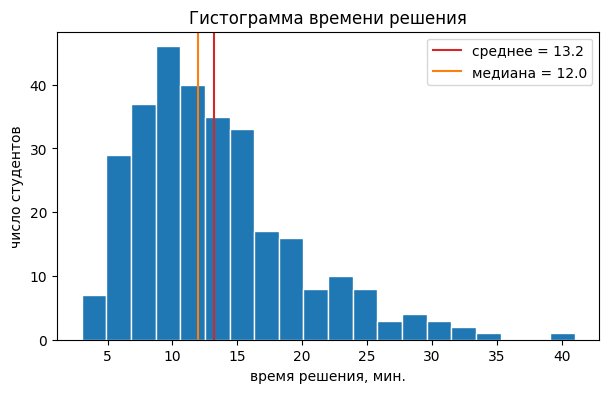

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(solve_time, bins=20, edgecolor='white')
plt.axvline(mean_time, color='tab:red', label=f'среднее = {mean_time:.1f}')
plt.axvline(median_time, color='tab:orange', label=f'медиана = {median_time:.1f}')
plt.xlabel('время решения, мин.')
plt.ylabel('число студентов')
plt.legend()
plt.title('Гистограмма времени решения')
plt.show()

### 4.2. Эмпирическая функция распределения

Эмпирическая функция распределения (ECDF) в точке $x$ — это доля выборки, не превышающая значения $x$.
Она строится без каких-либо предположений о распределении: просто сортируем данные, и для
`i`-го (начиная с 1) значения по возрастанию доля равна `i / n`.

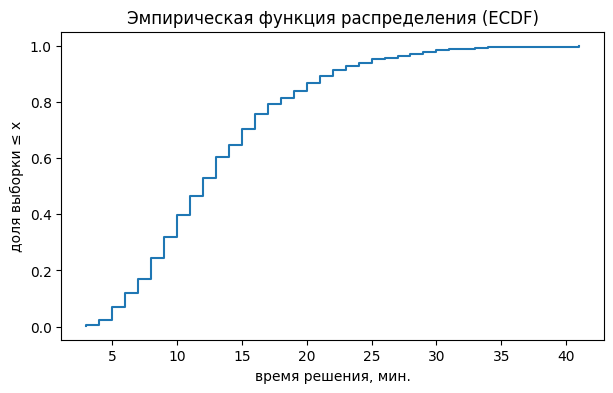

In [ ]:
sorted_time = np.sort(solve_time)
ecdf_y = np.arange(1, n + 1) / n

plt.figure(figsize=(7, 4))
plt.step(sorted_time, ecdf_y, where='post')
plt.xlabel('время решения, мин.')
plt.ylabel('доля выборки ≤ x')
plt.title('Эмпирическая функция распределения (ECDF)')
plt.show()

### 4.3. Перцентили

`np.percentile` — значение, ниже которого лежит заданный процент выборки: `percentile(x, 50)` —
это медиана, `percentile(x, 25)`/`percentile(x, 75)` — границы типичной середины выборки.

25%: 9.0   50% (медиана): 12.0   75%: 16.0   90%: 22.0


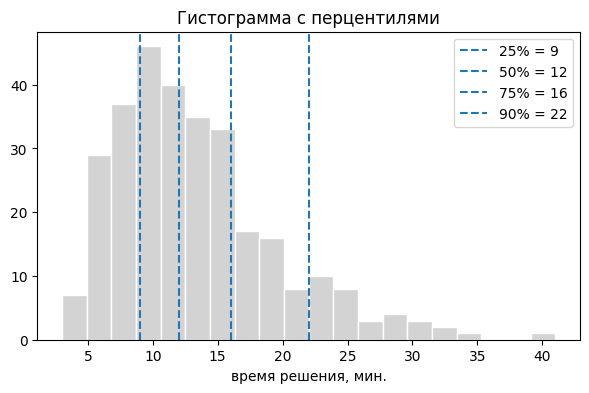

In [ ]:
p25, p50, p75, p90 = np.percentile(solve_time, [25, 50, 75, 90])
print(f'25%: {p25}   50% (медиана): {p50}   75%: {p75}   90%: {p90}')

plt.figure(figsize=(7, 4))
plt.hist(solve_time, bins=20, edgecolor='white', color='lightgray')
for p, label in [(p25, '25%'), (p50, '50%'), (p75, '75%'), (p90, '90%')]:
    plt.axvline(p, linestyle='--', label=f'{label} = {p:.0f}')
plt.legend()
plt.xlabel('время решения, мин.')
plt.title('Гистограмма с перцентилями')
plt.show()

#### Задача 11. Гистограмма, ECDF и перцентили для чеков

Используя `receipts` из задачи 9, постройте гистограмму и отметьте на ней вертикальными линиями
медиану и 90-й перцентиль; отдельно постройте ECDF. По ECDF (или гистограмме)  оцените на глаз долю
чеков меньше 1000 рублей, а затем проверьте расчётом через `np.mean(receipts < 1000)`.

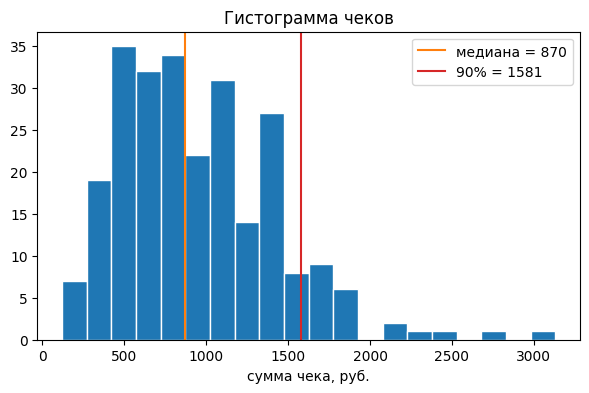

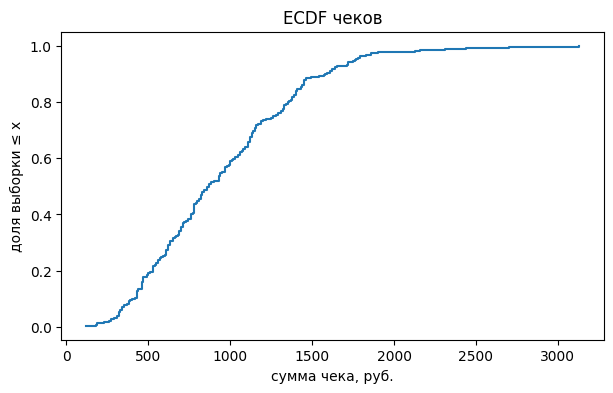

доля чеков < +1000 руб.: 0.576


In [ ]:
# Ваше решение здесь

# Решение
median_r = np.median(receipts)
p90_r = np.percentile(receipts, 90)

plt.figure(figsize=(7, 4))
plt.hist(receipts, bins=20, edgecolor='white')
plt.axvline(median_r, color='tab:orange', label=f'медиана = {median_r:.0f}')
plt.axvline(p90_r, color='tab:red', label=f'90% = {p90_r:.0f}')
plt.legend()
plt.xlabel('сумма чека, руб.')
plt.title('Гистограмма чеков')
plt.show()

sorted_r = np.sort(receipts)
ecdf_r = np.arange(1, len(receipts) + 1) / len(receipts)
plt.figure(figsize=(7, 4))
plt.step(sorted_r, ecdf_r, where='post')
plt.xlabel('сумма чека, руб.')
plt.ylabel('доля выборки ≤ x')
plt.title('ECDF чеков')
plt.show()

frac_below_1000 = np.mean(receipts < 1000)
print('доля чеков < +1000 руб.:', frac_below_1000)

In [ ]:
# Проверка
assert 0.4 < frac_below_1000 < 0.7
print('проверка пройдена')

проверка пройдена


## 5. Символьные вычисления: SymPy

В отличие от NumPy, который работает с числами, SymPy работает с математическими выражениями
**символьно** — так же, как вы бы решали задачу на бумаге: находит производные, интегралы,
решает уравнения аналитически, а не приближённо.

### 5.1. Дифференцирование

Найдём точку минимума параболы
$g(x) = x^2 - 4x + 7$ — через производную и решение уравнения $g'(x) = 0$.

In [ ]:
import sympy as S

x = S.symbols('x')
g = x**2 - 4*x + 7

dg = S.diff(g, x)
critical_points = S.solve(dg, x)

print('g(x)  =', g)
print("g'(x) =", dg)
print('критическая точка:', critical_points)
print('значение в этой точке:', g.subs(x, critical_points[0]))

g(x)  = x**2 - 4*x + 7
g'(x) = 2*x - 4
критическая точка: [2]
значение в этой точке: 3


### 5.2. Интегрирование



#### Задача 12. Константа нормировки

Плотность случайной величины $X$ задана следующим образом: $f(x) = c \cdot x$ на отрезке $[0, 2]$ и $0$ вне
отрезка. С помощью SymPy:

1. Найдите константу `c`, при которой $\int_0^2 f(x)\,dx = 1$ (используйте `S.integrate` и
   `S.solve`).
2. Подставив найденное `c`, вычислите $\mathbb{E}(X) = \int_0^2 x f(x)\, dx$ символьно.

In [ ]:
x, c = S.symbols('x c', positive=True)

# Ваше решение здесь

# Решение
density = c * x
normalization_eq = S.integrate(density, (x, 0, 2)) - 1     # должно равняться нулю
c_value = S.solve(normalization_eq, c)[0]

density_final = density.subs(c, c_value)
expected_value = S.integrate(x * density_final, (x, 0, 2))

print('c =', c_value)
print('f(x) =', density_final)
print('E[X] =', expected_value)

c = 1/2
f(x) = x/2
E[X] = 4/3


In [ ]:
# Проверка
assert c_value == S.Rational(1, 2)
assert expected_value == S.Rational(4, 3)
print('проверка пройдена')

проверка пройдена


SymPy вернул точные дробные значения (1/2, 4/3), а не приближения с плавающей точкой. В этом преимущество символьных вычислений.

### 5.3. Дифференцирование и интегрирование — взаимно обратные операции

Если проинтегрировать плотность $f(x)$ от $0$ до переменной верхней границы $x$, получится функция
распределения $F(x)$: вероятность того, что случайная величина не превосходит $x$. А если её продифференцировать обратно — мы должны получить исходную плотность.
Проверим это на найденной выше `density_final`.

In [ ]:
t = S.symbols('t', positive=True)

F = S.integrate(density_final.subs(x, t), (t, 0, x))   # F(x) = int_0^x f(t) dt
f_back = S.diff(F, x)                                     # обратно дифференцируем F(x)

print('F(x) =', F)
print("F'(x) =", f_back)
print('совпадает с исходной плотностью:', S.simplify(f_back - density_final) == 0)

F(x) = x**2/4
F'(x) = x/2
совпадает с исходной плотностью: True


## 6. Готовые модели распределений: SciPy

`scipy.stats` — каталог из сотни готовых распределений (и дискретных, и непрерывных) с единым
интерфейсом. Также можно задавать свои распределения.

### Набор методов для распределений

Каждое распределение в `scipy.stats` — `norm`, `binom`, `poisson`, `expon`, `gamma`, `t`,
`chi2` и так далее — имеет один и тот же набор методов:

| метод | что возвращает | для каких СВ |
|---|---|---|
| `.pmf(k, ...)` | Вероятность конкретного значения $P(X=k)$ | Только дискретные |
| `.pdf(x, ...)` | Значение плотности в точке $x$ | Только непрерывные |
| `.cdf(x, ...)` | Функция распределения $P(X \le x)$ | И те, и другие |
| `.ppf(q, ...)` | Квантильная функция (обратная к cdf) | И те, и другие |
| `.rvs(size=n, ...)` | Случайная выборка размера `n` | И те, и другие |
| `.mean()`, `.var()`, `.std()` | Теоретические характеристики | И те, и другие |
| `.interval(alpha)` | Центральный интервал, содержащий долю `alpha` вероятности | И те, и другие |

Параметры можно передавать при каждом вызове (`norm.cdf(x, loc=0, scale=1)`) либо один раз,
создав «замороженный» объект (`norm(loc=0, scale=1)`) — подробнее об этом в разделе 6.6.

In [ ]:
from scipy.stats import binom

n_trials, p_success = 10, 0.3
print('P(X = 3)      =', binom.pmf(3, n_trials, p_success))
print('P(X <= 3)     =', binom.cdf(3, n_trials, p_success))
print('квантиль 0.9  =', binom.ppf(0.9, n_trials, p_success))

X = binom(n=10, p=0.3)   # «замороженное» распределение -- параметры зафиксированы один раз
print(X.pmf(3), X.cdf(3), X.rvs(size=5, random_state=42))

P(X = 3)      = 0.26682793199999977
P(X <= 3)     = 0.6496107184000002
квантиль 0.9  = 5.0
0.26682793199999977 0.6496107184000002 [2 5 4 3 2]


### 6.2. Каталог распределений: что есть в scipy.stats

**Дискретные**

| Распределение | scipy.stats | Что моделирует |
|---|---|---|
| Бернулли | `bernoulli` | Один опыт с двумя исходами (успех/неудача) |
| Биномиальное | `binom` | Число успехов в `n` независимых испытаниях Бернулли |
| Геометрическое | `geom` | Номер первого успешного испытания |
| Отрицательное биномиальное | `nbinom` | Число неудач до `r`-го успеха |
| Гипергеометрическое | `hypergeom` | Число успехов при выборке без возврата (например, дефектных деталей) |
| Пуассона | `poisson` | Число редких событий за фиксированный интервал (звонки, отказы) |
| Дискретное равномерное | `randint` | Все целые в диапазоне равновероятны (кость) |

**Непрерывные**

| Распределение | scipy.stats | Что моделирует |
|---|---|---|
| Равномерное | `uniform` | Все значения на отрезке равновероятны |
| Нормальное | `norm` | Сумма множества независимых мелких эффектов (ЦПТ) |
| Экспоненциальное | `expon` | Время ожидания события в пуассоновском процессе |
| Гамма | `gamma` | Время ожидания `k`-го события (сумма `k` экспонент) |
| Бета | `beta` | Доля/вероятность на отрезке [0, 1] |
| Хи-квадрат | `chi2` | Сумма квадратов независимых стандартных нормальных величин |
| Стьюдента | `t` | Оценка среднего по малой выборке при неизвестной дисперсии |
| Фишера | `f` | Отношение двух независимых дисперсий (дисперсионный анализ) |
| Логнормальное | `lognorm` | Величина, чей логарифм нормален (доходы, размеры частиц) |
| Парето | `pareto` | Степенной «тяжёлый» хвост (доходы, размеры городов) |
| Коши | `cauchy` | Тяжёлые хвосты; у него не существует ни среднего, ни дисперсии |

Параметры распределений можно посмотреть в докстринге (`binom?` в Colab)
или в документации SciPy.

### 6.3. Внутренняя организация scipy.stats

`norm`, `binom`, `expon` — это экземпляры классов `norm_gen`, `binom_gen`, `expon_gen`, которые наследуются от общих базовых
классов:

```
rv_continuous                       rv_discrete
(cdf, ppf, rvs, mean,                (cdf, ppf, rvs, mean,
 var, interval -- общий                  var, interval -- общий
 численный алгоритм)                     численный алгоритм)
      |                                        |
      +-- norm_gen   (добавляет _pdf)          +-- binom_gen    (добавляет _pmf)
      +-- expon_gen  (добавляет _pdf)          +-- poisson_gen  (добавляет _pmf)
      +-- gamma_gen  (добавляет _pdf)          +-- ...
      +-- ...
```

`cdf`, `ppf`, `rvs`, `mean`, `var` у **всех** распределений считаются одним и тем же
универсальным алгоритмом, реализованным один раз в `rv_continuous`/`rv_discrete`:

- `cdf` — численный интеграл от плотности (если у наследника нет своей быстрой формулы);
- `ppf` — численный поиск корня уравнения `cdf(x) = q`;
- `rvs` — метод обратного преобразования: генерируем `U ~ Unif(0,1)` и считаем `ppf(U)`;
- `mean`, `var` — численное интегрирование.

Каждому конкретному распределению остаётся добавить только то, что у него уникально
— обычно формулу плотности `_pdf` (или `_pmf` для дискретных). Всё остальное наследуется.

In [ ]:
print(type(stats.norm))                            # это объект какого-то класса, не сам класс
print(type(stats.norm).__bases__)                     # у класса norm_gen есть родитель
print(isinstance(stats.norm, stats.rv_continuous))     # norm -- экземпляр rv_continuous
print(isinstance(stats.poisson, stats.rv_discrete))    # то же самое для дискретных

<class 'scipy.stats._continuous_distns.norm_gen'>
(<class 'scipy.stats._distn_infrastructure.rv_continuous'>,)
True
True


### 6.4. Кастомное непрерывное распределение

Если нужного распределения нет в каталоге, `cdf`/`ppf`/`rvs` не нужно писать вручную — достаточно
унаследоваться от `rv_continuous` и переопределить `_pdf`. Всё остальное придёт по наследованию.

Возьмём плотность $f(x) = 2x$ на отрезке $[0, 1]$.

In [ ]:
class LinearDist(stats.rv_continuous):
    def _pdf(self, x):
        return 2 * x   # единственное, что мы описываем сами

linear_dist = LinearDist(a=0, b=1, name='linear')   # a, b -- границы носителя

print('cdf(0.5)  =', linear_dist.cdf(0.5))     # cdf, ppf, mean, rvs -- унаследованы
print('ppf(0.25) =', linear_dist.ppf(0.25))     # от rv_continuous, мы их не писали
print('mean      =', linear_dist.mean())
print('rvs(5)    =', linear_dist.rvs(size=5, random_state=0))

cdf(0.5)  = 0.25
ppf(0.25) = 0.49999999999999994
mean      = 0.6666666666666667
rvs(5)    = [0.74081948 0.84568869 0.77637837 0.73816203 0.6508877 ]


### 6.5. Кастомное дискретное распределение (два способа)

**Способ 1 — конечная таблица значений.** Если у величины конечное число исходов, таблицу
`(значения, вероятности)` можно сразу передать в `stats.rv_discrete(values=...)`, ничего не
наследуя — scipy сам построит нужный класс.

In [ ]:
from scipy import stats
import numpy as np

# нечестная кость: 1..5 равновероятны, а 6 выпадает в 5 раз чаще
xk = np.arange(1, 7)
pk = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.5])

loaded_die = stats.rv_discrete(name='loaded_die', values=(xk, pk))

print('pmf(6)  =', loaded_die.pmf(6))
print('mean    =', loaded_die.mean())
print('var     =', loaded_die.var())
print('rvs(10) =', loaded_die.rvs(size=10, random_state=0))

pmf(6)  = 0.5
mean    = 4.5
var     = 3.25
rvs(10) = [6 6 6 6 5 6 5 6 6 4]


#### Задача 13. Сумма двух костей как объект распределения

В разделе 2 (Монте-Карло) мы вручную построили таблицу сумм двух костей через broadcasting.
Обернём эту же таблицу вероятностей в `stats.rv_discrete`, чтобы получить `mean`/`var`/`interval`
готовыми, не считая их самостоятельно.

Постройте `stats.rv_discrete` для суммы двух костей (значения от 2 до 12, вероятности
$p_k = \dfrac{6 - |7-k|}{36}$) и с помощью `.interval(0.9)` найдите центральный интервал,
накрывающий 90% вероятности.

In [ ]:
# Ваше решение здесь

# Решение
xk = np.arange(2, 13)
pk = (6 - np.abs(7 - xk)) / 36

dice_sum_dist = stats.rv_discrete(name='dice_sum', values=(xk, pk))

mean_check = dice_sum_dist.mean()
interval_90 = dice_sum_dist.interval(0.9)

print('mean =', mean_check)
print('90%-й центральный интервал:', interval_90)

mean = 6.999999999999998
90%-й центральный интервал: (np.float64(3.0), np.float64(11.0))


In [ ]:
# Проверка
assert np.isclose(pk.sum(), 1.0)
assert np.isclose(mean_check, 7.0)
assert interval_90[0] <= 7 <= interval_90[1]
print('проверка пройдена')

проверка пройдена


**Способ 2 — произвольная формула, через наследование.** Если исходов счётно или
распределение зависит от параметра — нужен `_pmf`, как и `_pdf` у непрерывных величин. Параметры
формы (здесь это количество точек `n`) становятся дополнительными аргументами `_pmf` и передаются при каждом вызове.

Возьмём «треугольное» распределение: $P(k)$ пропорциональна $k$ на $\{1, \dots, n\}$.

In [ ]:
class TriangularCounts(stats.rv_discrete):
    def _pmf(self, k, n):
        return k / (n * (n + 1) / 2)

tri = TriangularCounts(name='triangular_counts', a=1, b=5)

xk_tri = np.arange(1, 6)
print('pmf:  ', tri.pmf(xk_tri, n=5))
print('mean: ', tri.mean(n=5), ' (теория: 11/3 =', 11/3, ')')
print('rvs:  ', tri.rvs(n=5, size=8, random_state=0))

pmf:   [0.06666667 0.13333333 0.2        0.26666667 0.33333333]
mean:  3.6666666666666665  (теория: 11/3 = 3.6666666666666665 )
rvs:   [4 5 4 4 4 4 4 5]


#### Задача 14. Собственное непрерывное распределение

Через наследование от `stats.rv_continuous` реализуйте распределение с плотностью $f(x) = 3x^2$ на
отрезке $[0, 1]$ (переопределите только `_pdf`). Используя унаследованные методы, проверьте:

- `cdf(1)` близко к 1 (плотность нормирована правильно);
- теоретическое `mean()` близко к аналитическому значению $\mathbb{E}[X] = \int_0^1 x \cdot 3x^2\,dx = 3/4$;
- эмпирическое среднее выборки `rvs(size=20000)` близко к тому же значению 3/4.

In [ ]:
# Ваше решение здесь

# Решение
class PowerDist(stats.rv_continuous):
    def _pdf(self, x):
        return 3 * x ** 2

power_dist = PowerDist(a=0, b=1, name='power')

cdf_at_1 = power_dist.cdf(1)
theoretical_mean = power_dist.mean()
sample = power_dist.rvs(size=20_000, random_state=1)
empirical_mean = np.mean(sample)

print('cdf(1)                =', cdf_at_1)
print('mean() (теория)        =', theoretical_mean)
print('mean(rvs) (эмпирика)   =', empirical_mean)

cdf(1)                = 1.0
mean() (теория)        = 0.7499999999999999
mean(rvs) (эмпирика)   = 0.7504946171476757


In [ ]:
# Проверка
assert np.isclose(cdf_at_1, 1.0, atol=1e-6)
assert np.isclose(theoretical_mean, 0.75, atol=1e-6)
assert np.isclose(empirical_mean, 0.75, atol=0.02)
print('проверка пройдена')

проверка пройдена


### 6.6. Frozen-распределения: замораживаем параметры

`norm.cdf(x, loc=0, scale=1)` каждый раз требует передавать `loc`/`scale` заново. Если с одним и
тем же распределением предстоит работать много раз, параметры можно «заморозить» один раз, вызвав
распределение как функцию: `norm(loc=0, scale=1)`.

Это возвращает **отдельный объект** — «замороженное» распределение, которое само помнит свои
параметры и подставляет их в каждый метод.

In [ ]:
frozen = stats.norm(loc=10, scale=2)   # параметры зафиксированы один раз

print(frozen.cdf(10))                        # не нужно повторять loc=10, scale=2
print(stats.norm.cdf(10, loc=10, scale=2))     # то же самое, но многословнее
print(frozen.mean(), frozen.std())

print(type(frozen).__name__)   # rv_continuous_frozen -- отдельный класс-обёртка

0.5
0.5
10.0 2.0
rv_continuous_frozen


Замораживать удобно по двум причинам:
* не нужно повторять одни и те же `loc`/`scale`/`n`/`p` в
каждом вызове (снижает риск ошибки при копировании между вызовами);
* распределение с зафиксированными
параметрами можно передать в другую функцию или сохранить в переменную как единый объект.

### 6.7. Теория и выборка на одном графике

Соберём вместе всё, что было в лекции: сгенерируем большую выборку из распределения (`rvs`,
раздел 2 — метод Монте-Карло), построим по ней гистограмму (раздел 4 — визуализация) и наложим
на неё теоретическую `pmf`. Чем больше выборка, тем ближе гистограмма к теоретической форме.

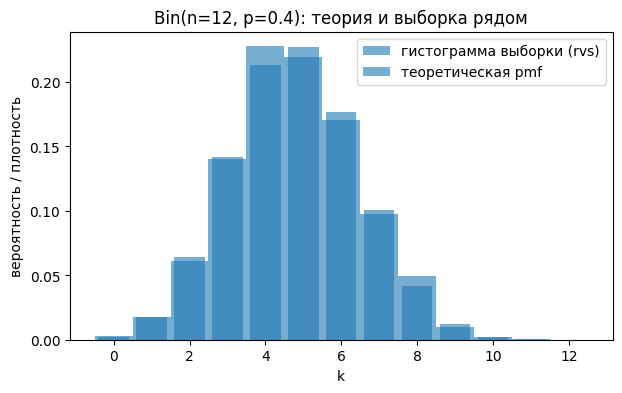

In [ ]:
n_trials, p_success = 12, 0.4
k_values = np.arange(0, n_trials + 1)
pmf_values = binom.pmf(k_values, n_trials, p_success)
sample = binom.rvs(n_trials, p_success, size=5000, random_state=0)

plt.figure(figsize=(7, 4))
plt.bar(k_values, pmf_values, alpha=0.6, label='теоретическая pmf')
plt.hist(sample, bins=np.arange(-0.5, n_trials + 1.5, 1), density=True, alpha=0.6,
         label='гистограмма выборки (rvs)')
plt.xlabel('k')
plt.ylabel('вероятность / плотность')
plt.legend()
plt.title(f'Bin(n={n_trials}, p={p_success}): теория и выборка рядом')
plt.show()

## Итоги

- **NumPy** — векторизация вместо циклов; суммирование, поэлементное умножение и скалярное
  произведение (`@`) вплоть до матричного умножения; различие view/copy при индексации;
  маскированные массивы для «грязных» данных.
- **Метод Монте-Карло** — вместо формулы можно смоделировать много случайных экспериментов и
  оценить нужную величину по доле/среднему; результат всегда близок к теории, но не совпадает с
  ней в точности — поэтому числа сравниваются через `np.isclose`/`np.allclose`, а не через `==`.
- **Характеристики выборки** — среднее, медиана, мода (центр); дисперсия, среднеквадратическое отклонение (разброс);
  асимметрия, эксцесс (форма); ковариация, корреляция (связь двух переменных).
- **Визуализация** — `plt.hist` (гистограмма), эмпирическая функция распределения (ECDF),
  `np.percentile` для перцентилей.
- **Sympy** — символьные вычисления: дифференцирование, интегрирование, точные (не приближённые)
  ответы там, где важна аналитическая точность.
- **SciPy (`scipy.stats`)** — каталог готовых распределений с единым набором методов
  (`pmf`/`pdf`/`cdf`/`ppf`/`rvs`/`mean`/`var`/`interval`); все они наследуются от
  `rv_continuous`/`rv_discrete`, поэтому своё распределение можно описать, переопределив
  только `_pdf`/`_pmf`; `norm(loc=..., scale=...)` замораживает параметры в один объект.
